# General import tasks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [2]:
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
import math

# Bikeshare dataset processing
https://www.kaggle.com/competitions/bike-sharing-demand/data?select=train.csv

In [4]:
# read in the data
bikeshare_df = pd.read_csv('bikeshare_train.csv')
bikeshare_train_df = bikeshare_df[:math.floor(len(bikeshare_df)*0.8)]
bikeshare_test_df = bikeshare_df[math.ceil(len(bikeshare_df)*0.8):]
bikeshare_kaggle_test_df = pd.read_csv('bikeshare_test.csv')

In [5]:
# show head of data
bikeshare_train_df[:5]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
# 1. Data Preparation (Bikeshare Dataset)
features_multi = ['temp', 'humidity', 'windspeed']
target = 'count'

# Scaling is MANDATORY for Gradient Descent/SGD
scaler = StandardScaler()
bikeshare_train_all_scaled = scaler.fit_transform(bikeshare_train_df[features_multi])
bikeshare_train_y = bikeshare_train_df[target].values

In [7]:
# 1. Scale your testing features (must use the same scaler as training!)
bikeshare_test_full_scaled = scaler.transform(bikeshare_test_df[['temp', 'humidity', 'windspeed']])

#  Medical Cost Personal Datasets processing
https://www.kaggle.com/datasets/mirichoi0218/insurance

In [8]:
insurance_df_raw = pd.read_csv('insurance.csv')

In [9]:
# Converting categories to numbers for the model
insurance_df = pd.get_dummies(insurance_df_raw, columns=['sex', 'smoker', 'region'], drop_first=True)

In [10]:
# split into train and test
insurance_train_df = insurance_df[:math.floor(len(insurance_df)*0.8)]
insurance_test_df = insurance_df[math.ceil(len(insurance_df)*0.8):]

In [11]:
# show head of data
insurance_train_df[:5]

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [12]:
# Target variable (Charges)
# Isolate the target (y) for both sets
insurance_y_train = insurance_train_df['charges'].values
insurance_y_test = insurance_test_df['charges'].values

# Create feature sets (X) by dropping the target
insurance_X_train_all = insurance_train_df.drop('charges', axis=1)
insurance_X_test_all = insurance_test_df.drop('charges', axis=1)

scaler = StandardScaler()

In [13]:
# Use 'age' as the single independent variable [cite: 31]
insurance_X_train_simple = scaler.fit_transform(insurance_X_train_all[['age']])

# transform for testing
insurance_X_test_simple = scaler.transform(insurance_X_test_all[['age']])

# simple linear regression
### Bikeshare dataset

In [14]:
chunk_count = 10
bikeshare_record_count = len(bikeshare_train_df)
bikeshare_chunk_size = bikeshare_record_count // chunk_count

print((chunk_count, bikeshare_record_count, bikeshare_chunk_size), )

(10, 8708, 870)


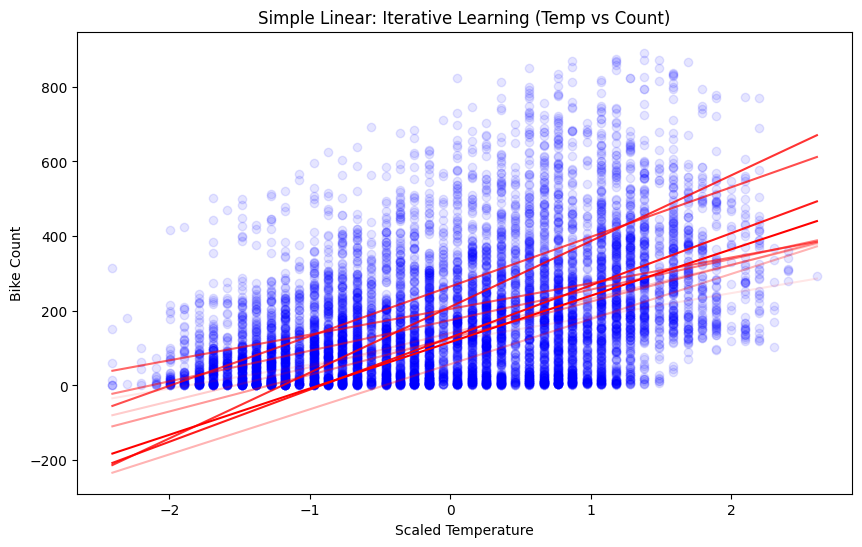

In [15]:
bikeshare_train_x_simple = bikeshare_train_all_scaled[:, [0]] # Just 'temp'
model_simple = SGDRegressor(learning_rate='constant', eta0=0.01)

plt.figure(figsize=(10, 6))
plt.scatter(bikeshare_train_x_simple, bikeshare_train_y, color='blue', alpha=0.1, label='Data Points')

for i in range(0, bikeshare_record_count, bikeshare_chunk_size):
    model_simple.partial_fit(bikeshare_train_x_simple[i:i + bikeshare_chunk_size], bikeshare_train_y[i:i + bikeshare_chunk_size])

    # Plotting the intermediate line
    bikeshare_x_range = np.linspace(bikeshare_train_x_simple.min(), bikeshare_train_x_simple.max(), 100).reshape(-1, 1)

    # plot the predicted line for each chunk, getting darker with each "pass"
    plt.plot(bikeshare_x_range, model_simple.predict(bikeshare_x_range), color='red', alpha=i / bikeshare_record_count)

plt.title("Simple Linear: Iterative Learning (Temp vs Count)")
plt.xlabel("Scaled Temperature")
plt.ylabel("Bike Count")
plt.show()

-200 bikes?? 🤨

In [16]:
# Slice out only the 'temp' column (index 0) for your simple model
# This matches the [:, [0]] slicing you used during training
bikeshare_x_test_simple_scaled = bikeshare_test_full_scaled[:, [0]]

bikeshare_y_test = bikeshare_test_df['count'].values

# 2. Predict on the unseen testing data
bikeshare_y_pred = model_simple.predict(bikeshare_x_test_simple_scaled)

# 3. Calculate Key Metrics
bikeshare_simple_r2 = r2_score(bikeshare_y_test, bikeshare_y_pred)
bikeshare_simple_rmse = np.sqrt(mean_squared_error(bikeshare_y_test, bikeshare_y_pred))

print(f"R-squared: {bikeshare_simple_r2:.4f}")
print(f"RMSE: {bikeshare_simple_rmse:.2f}")

R-squared: -0.3264
RMSE: 250.59


### insurance dataset

In [17]:
insurance_train_record_count = len(insurance_X_train_simple)
insurance_train_chunk_size = insurance_train_record_count // chunk_count

print((chunk_count, insurance_train_record_count, insurance_train_chunk_size), )

(10, 1070, 107)


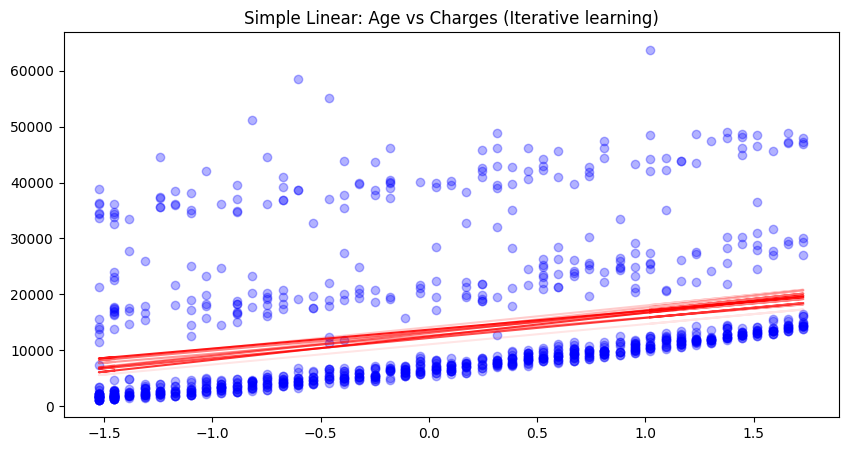

In [18]:
model_simple = SGDRegressor(learning_rate='constant', eta0=0.01)

plt.figure(figsize=(10, 5))
plt.scatter(insurance_X_train_simple, insurance_y_train, alpha=0.3, color='blue', label='Actual Data')

# Showing the iterative "Gradient Descent" steps [cite: 206]
for i in range(0, insurance_train_record_count, insurance_train_chunk_size):
    model_simple.partial_fit(insurance_X_train_simple[i:i+100], insurance_y_train[i:i+100])
    plt.plot(insurance_X_train_simple, model_simple.predict(insurance_X_train_simple), color='red', alpha=i/insurance_train_record_count)

plt.title("Simple Linear: Age vs Charges (Iterative learning)")
plt.show()

- strong clustering, throws off a weighted regression model
- cant approximate all data
- while this is easy to explain, it could be dangerously wrong

In [19]:
# Simple insurance model: use only the 'age' feature

# Keep a dedicated scaler for the simple model
age_scaler = StandardScaler()

# Fit only on the training 'age' column
insurance_X_train_simple = age_scaler.fit_transform(insurance_X_train_all[['age']])

# Transform the test 'age' column using the same scaler
insurance_X_test_simple = age_scaler.transform(insurance_X_test_all[['age']])

# Train the model if needed
model_simple = SGDRegressor(learning_rate='constant', eta0=0.01)
model_simple.partial_fit(insurance_X_train_simple, insurance_y_train)

# Predict
insurance_y_pred = model_simple.predict(insurance_X_test_simple)

# Evaluate
insurance_simple_r2 = r2_score(insurance_y_test, insurance_y_pred)
insurance_simple_rmse = np.sqrt(mean_squared_error(insurance_y_test, insurance_y_pred))

print(f"R-squared: {insurance_simple_r2:.4f}")
print(f"RMSE: {insurance_simple_rmse:.2f}")

R-squared: 0.0460
RMSE: 12037.22


technically better than mean!

# Multiple Linear Regression
### Bikeshare dataset

In [20]:
model_multi = SGDRegressor(learning_rate='adaptive', eta0=0.001, max_iter=1, warm_start=True)

for i in range(0, bikeshare_record_count, bikeshare_chunk_size):
    model_multi.partial_fit(
        bikeshare_train_all_scaled[i:i + bikeshare_chunk_size],
        bikeshare_train_y[i:i + bikeshare_chunk_size]
    )

bikeshare_multi_pred = model_multi.predict(bikeshare_test_full_scaled)

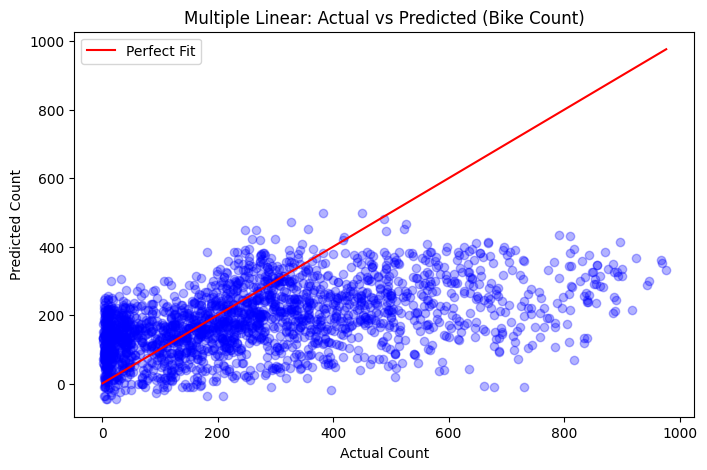

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(bikeshare_y_test, bikeshare_multi_pred, alpha=0.3, color='blue')
plt.plot([bikeshare_y_test.min(), bikeshare_y_test.max()],
         [bikeshare_y_test.min(), bikeshare_y_test.max()], color='red', label='Perfect Fit')
plt.title('Multiple Linear: Actual vs Predicted (Bike Count)')
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.legend()
plt.show()

In [22]:
bikeshare_multi_pred = model_multi.predict(bikeshare_test_full_scaled)
bikeshare_multi_r2 = r2_score(bikeshare_y_test, bikeshare_multi_pred)
bikeshare_multi_mse = np.sqrt(mean_squared_error(bikeshare_y_test, bikeshare_multi_pred))
print(f"R-squared: {bikeshare_multi_r2:.3f} (bikeshare_multi_r2)")
print(f"RMSE: {bikeshare_multi_mse:.2f}")

R-squared: 0.108 (bikeshare_multi_r2)
RMSE: 205.52


### insurance dataset

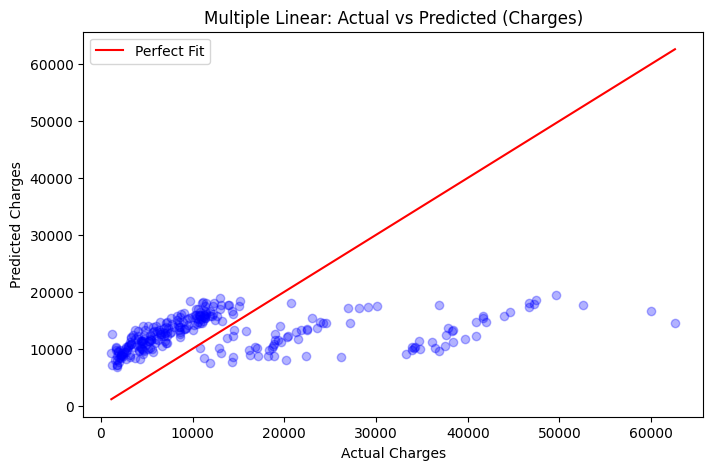

In [23]:
# Multiple Linear Regression - Insurance
model_multi = SGDRegressor(learning_rate='adaptive', eta0=0.0001, max_iter=1, warm_start=True)

for i in range(0, insurance_train_record_count, insurance_train_chunk_size):
    model_multi.partial_fit(
        insurance_X_train_all[i:i + insurance_train_chunk_size],
        insurance_y_train[i:i + insurance_train_chunk_size]
    )

insurance_multi_pred = model_multi.predict(insurance_X_test_all)

plt.figure(figsize=(8, 5))
plt.scatter(insurance_y_test, insurance_multi_pred, alpha=0.3, color='blue')
plt.plot([insurance_y_test.min(), insurance_y_test.max()],
         [insurance_y_test.min(), insurance_y_test.max()], color='red', label='Perfect Fit')
plt.title('Multiple Linear: Actual vs Predicted (Charges)')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.legend()
plt.show()

In [24]:
insurance_multi_r2 = r2_score(insurance_y_test, insurance_multi_pred)
insurance_multi_mse = np.sqrt(mean_squared_error(insurance_y_test, insurance_multi_pred))
print(f"R-squared: {insurance_multi_r2:.3f} (insurance_multi_r2)")
print(f"RMSE: {insurance_multi_mse:.2f}")

R-squared: 0.099 (insurance_multi_r2)
RMSE: 11698.19


Note: poor performance expected, charges have a non-linear relationship driven by smoker status creating two distinct cost clusters polynomial regression should capture this better

# Polynomial Regression
### Bikeshare dataset

/home/joseph/Documents/cs422/presentation/demo/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/joseph/Documents/cs422/presentation/demo/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/joseph/Documents/cs422/presentation/demo/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/joseph/Documents/cs422/presentation/demo/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/joseph/Documents/cs422/presentation/demo/.

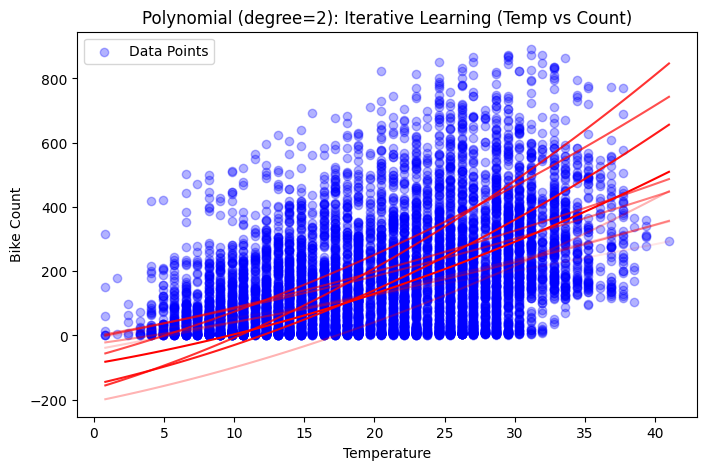

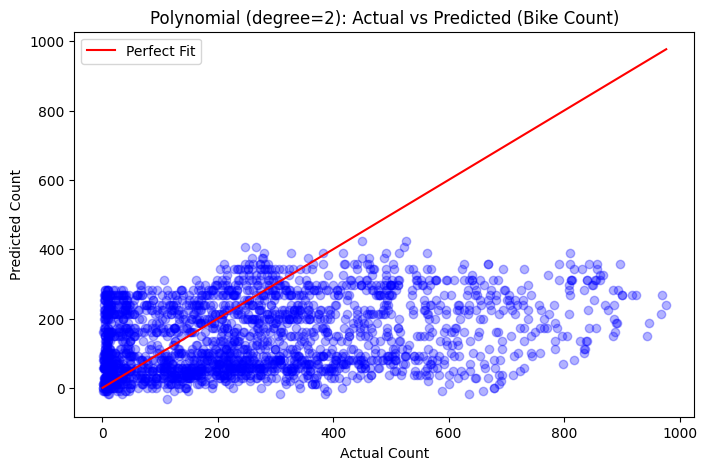

In [29]:
# Polynomial Regression (degree=2) - Bikeshare
poly = PolynomialFeatures(degree=2)

bikeshare_train_x_poly = poly.fit_transform(bikeshare_train_df[['temp']])
bikeshare_test_x_poly = poly.transform(bikeshare_test_df[['temp']])

scaler_poly_bike = StandardScaler()
bikeshare_train_x_poly_scaled = scaler_poly_bike.fit_transform(bikeshare_train_x_poly)
bikeshare_test_x_poly_scaled = scaler_poly_bike.transform(bikeshare_test_x_poly)

model_poly = SGDRegressor(learning_rate='adaptive', eta0=0.01, max_iter=1, warm_start=True)

plt.figure(figsize=(8, 5))
plt.scatter(bikeshare_train_df['temp'], bikeshare_train_y, color='blue', alpha=0.3, label='Data Points')

for i in range(0, bikeshare_record_count, bikeshare_chunk_size):
    model_poly.partial_fit(
        bikeshare_train_x_poly_scaled[i:i + bikeshare_chunk_size],
        bikeshare_train_y[i:i + bikeshare_chunk_size]
    )
    bikeshare_x_range = np.linspace(bikeshare_train_df['temp'].min(), bikeshare_train_df['temp'].max(), 100).reshape(-1, 1)
    bikeshare_x_range_poly = poly.transform(bikeshare_x_range)
    bikeshare_x_range_poly_scaled = scaler_poly_bike.transform(bikeshare_x_range_poly)
    plt.plot(bikeshare_x_range, model_poly.predict(bikeshare_x_range_poly_scaled),
             color='red', alpha=i / bikeshare_record_count)

plt.title('Polynomial (degree=2): Iterative Learning (Temp vs Count)')
plt.xlabel('Temperature')
plt.ylabel('Bike Count')
plt.legend()
plt.show()

bikeshare_poly_pred = model_poly.predict(bikeshare_test_x_poly_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(bikeshare_y_test, bikeshare_poly_pred, alpha=0.3, color='blue')
plt.plot([bikeshare_y_test.min(), bikeshare_y_test.max()],
         [bikeshare_y_test.min(), bikeshare_y_test.max()], color='red', label='Perfect Fit')
plt.title('Polynomial (degree=2): Actual vs Predicted (Bike Count)')
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.legend()
plt.show()

In [26]:
bikeshare_poly_pred = model_poly.predict(bikeshare_test_x_poly_scaled)
bikeshare_poly_r2 = r2_score(bikeshare_y_test, bikeshare_poly_pred)
bikeshare_poly_mse = np.sqrt(mean_squared_error(bikeshare_y_test, bikeshare_poly_pred))
print(f"R-squared: {bikeshare_poly_r2:.3f} (bikeshare_poly_r2)")
print(f"RMSE: {bikeshare_poly_mse:.2f}")

R-squared: -0.276 (bikeshare_poly_r2)
RMSE: 245.76


Note: polynomial offers no improvement over multiple linear for this dataset suggesting the relationship between weather features and ridership is largely linear

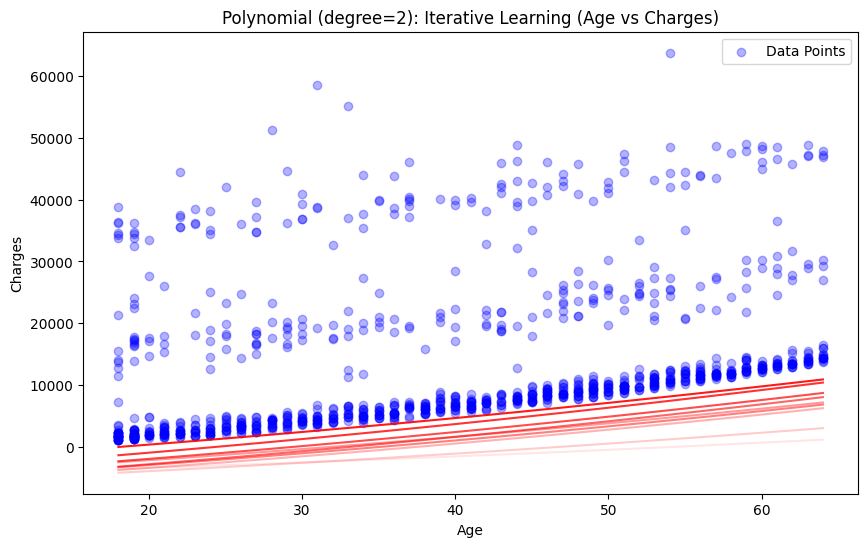

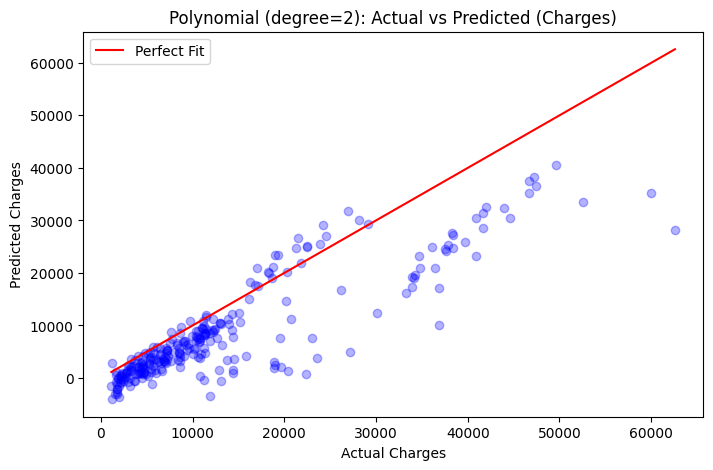

In [27]:
# Polynomial Regression (degree=2) - Insurance
poly_insurance = PolynomialFeatures(degree=2)

insurance_train_x_poly = poly_insurance.fit_transform(insurance_X_train_all)
insurance_test_x_poly = poly_insurance.transform(insurance_X_test_all)

scaler_poly_ins = StandardScaler()
insurance_train_x_poly_scaled = scaler_poly_ins.fit_transform(insurance_train_x_poly)
insurance_test_x_poly_scaled = scaler_poly_ins.transform(insurance_test_x_poly)

model_poly = SGDRegressor(learning_rate='adaptive', eta0=0.001, max_iter=1, warm_start=True)

plt.figure(figsize=(10, 6))
plt.scatter(insurance_X_train_all['age'], insurance_y_train, alpha=0.3, color='blue', label='Data Points')

for i in range(0, insurance_train_record_count, insurance_train_chunk_size):
    model_poly.partial_fit(
        insurance_train_x_poly_scaled[i:i + insurance_train_chunk_size],
        insurance_y_train[i:i + insurance_train_chunk_size]
    )
    
    # Create range for visualization
    age_range = np.linspace(insurance_X_train_all['age'].min(), insurance_X_train_all['age'].max(), 100).reshape(-1, 1)
    age_range_df = pd.DataFrame(age_range, columns=['age'])
    
    # Add other features with median values for prediction
    for col in insurance_X_train_all.columns:
        if col != 'age':
            age_range_df[col] = insurance_X_train_all[col].median()
    
    # Transform and scale for prediction
    age_range_poly = poly_insurance.transform(age_range_df)
    age_range_poly_scaled = scaler_poly_ins.transform(age_range_poly)
    
    # Plot iterative learning line
    plt.plot(age_range, model_poly.predict(age_range_poly_scaled), 
             color='red', alpha=i / insurance_train_record_count)

plt.title('Polynomial (degree=2): Iterative Learning (Age vs Charges)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.show()

insurance_poly_pred = model_poly.predict(insurance_test_x_poly_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(insurance_y_test, insurance_poly_pred, alpha=0.3, color='blue')
plt.plot([insurance_y_test.min(), insurance_y_test.max()],
         [insurance_y_test.min(), insurance_y_test.max()], color='red', label='Perfect Fit')
plt.title('Polynomial (degree=2): Actual vs Predicted (Charges)')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.legend()
plt.show()

In [28]:
insurance_poly_pred = model_poly.predict(insurance_test_x_poly_scaled)
insurance_poly_r2 = r2_score(insurance_y_test, insurance_poly_pred)
insurance_poly_mse = np.sqrt(mean_squared_error(insurance_y_test, insurance_poly_pred))
print(f"R-squared: {insurance_poly_r2:.3f} (insurance_poly_r2)")
print(f"RMSE: {insurance_poly_mse:.2f}")

R-squared: 0.623 (insurance_poly_r2)
RMSE: 7571.87
